<a href="https://colab.research.google.com/github/mahathimallela/OMIS-3020-Final-Group-Project-Heart-Disease/blob/main/OMIS_3020_Final_Project_EDA_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#OMIS 3020 FINAL PROJECT
##**Exploratory Data Analysis**




In [1]:
#setting up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importing the data as an excel file and into a dataframe. The data was retrieved from Kaggle at: https://www.kaggle.com/datasets/rhythmghai/synthetic-heart-disease-risk-prediction-dataset

In [2]:
#reading file into dataframe
df=pd.read_csv('synthetic_heart_disease_risk_dataset-2.csv')
df.head(5)

,Age,Gender,Resting_BP,Cholesterol,Fasting_Blood_Sugar,Max_Heart_Rate,ECG_Result,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Quality_Score,Sleep_Hours,BMI,Diabetes,Hypertension,Family_History,Risk_Score,Risk_Level,Heart_Disease
0,62,Male,99.894739,165.758273,84.162807,163.936710,Normal,Never,2.872268,High,8.790862,4.646630,17.795653,0,1,1,28.09,Low,0
1,52,Female,106.770004,214.438911,70.835367,173.401040,Normal,Never,1.023415,Low,6.667920,4.763242,21.204699,0,0,0,16.27,Low,0
2,64,Male,136.693974,183.733097,70.000000,159.404482,Normal,Current,1.632548,Low,5.642529,8.960664,28.986249,0,1,0,43.55,Medium,0
3,77,Male,152.216653,142.226109,92.093394,156.585345,ST,Current,1.236023,Moderate,7.924200,7.517319,24.998951,0,1,0,50.84,Medium,0
4,51,Female,118.930670,174.057381,161.157991,171.130750,ST,Current,1.752441,High,7.040169,6.904060,23.435718,1,0,0,40.87,Medium,0


#**1. Data Overview & Quality Check**:

Before any analysis, we inspect the dataset's shape, data types, and missing values to understand what we're working with and confirm it's ready for exploration.

In [3]:
df.shape

(12000, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      12000 non-null  int64  
 1   Gender                   12000 non-null  object 
 2   Resting_BP               12000 non-null  float64
 3   Cholesterol              12000 non-null  float64
 4   Fasting_Blood_Sugar      12000 non-null  float64
 5   Max_Heart_Rate           12000 non-null  float64
 6   ECG_Result               12000 non-null  object 
 7   Smoking_Status           12000 non-null  object 
 8   Alcohol_Consumption      12000 non-null  float64
 9   Physical_Activity_Level  12000 non-null  object 
 10  Diet_Quality_Score       12000 non-null  float64
 11  Sleep_Hours              12000 non-null  float64
 12  BMI                      12000 non-null  float64
 13  Diabetes                 12000 non-null  int64  
 14  Hypertension          

In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Resting_BP,0
Cholesterol,0
Fasting_Blood_Sugar,0
Max_Heart_Rate,0
ECG_Result,0
Smoking_Status,0
Alcohol_Consumption,0
Physical_Activity_Level,0


In [6]:
df.describe()

,Age,Resting_BP,Cholesterol,Fasting_Blood_Sugar,Max_Heart_Rate,Alcohol_Consumption,Diet_Quality_Score,Sleep_Hours,BMI,Diabetes,Hypertension,Family_History,Risk_Score,Heart_Disease
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,54.412833,117.539021,190.444011,103.883279,165.487949,2.276436,5.994206,7.000880,25.619445,0.220667,0.368833,0.291750,32.116545,0.009833
std,14.773132,15.995856,31.218109,29.083481,17.813561,1.401028,1.906219,0.982620,3.567003,0.414713,0.482509,0.454587,13.564508,0.098679
min,18.000000,90.000000,120.000000,70.000000,92.948500,0.005550,1.000000,4.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,105.800302,168.992542,83.206073,153.376497,1.141569,4.685094,6.336578,23.184382,0.000000,0.000000,0.000000,21.707500,0.000000
50%,54.000000,117.399988,190.323317,95.452088,165.404509,2.004490,5.981614,7.010829,25.565344,0.000000,0.000000,0.000000,31.520000,0.000000
75%,64.000000,128.348874,212.015963,115.377310,177.729980,3.206427,7.298645,7.687658,28.040627,0.000000,1.000000,1.000000,41.380000,0.000000
max,90.000000,179.047975,302.803018,200.000000,210.000000,5.000000,10.000000,9.000000,38.025665,1.000000,1.000000,1.000000,82.800000,1.000000


In [7]:
df['Heart_Disease'].value_counts(normalize=True)
df['Risk_Level'].value_counts(normalize=True)

,proportion
Risk_Level,
Low,0.600083
Medium,0.390167
High,0.009750


**Observations:**
- The dataset contains **12,000 rows and 19 columns** with no missing values — it is fully clean.
- Features fall into three groups:
  - **Continuous floats:** `Resting_BP`, `Cholesterol`, `BMI`, `Risk_Score`, etc.
  - **Binary integers:** `Diabetes`, `Hypertension`, `Family_History`, `Heart_Disease`
  - **Categorical strings:** `Gender`, `ECG_Result`, `Smoking_Status`, `Physical_Activity_Level`, `Risk_Level`
- No data cleaning or imputation is required before analysis.

#**2. Target Variable Distributions**

We examine the distribution of both target variables to check for class imbalance, which can affect model performance and interpretation.




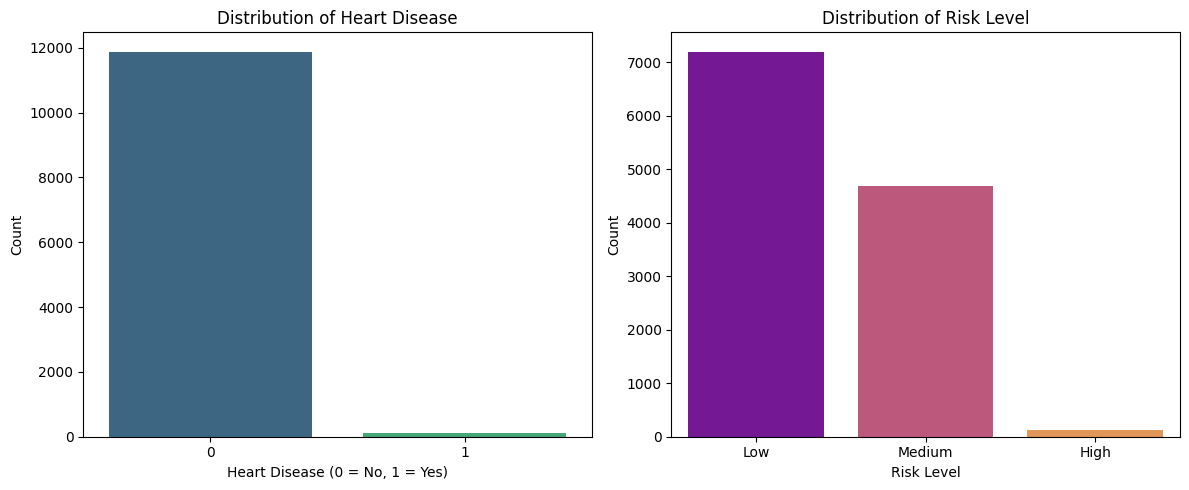

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

# Count plot for Heart_Disease
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(data=df, x='Heart_Disease', hue='Heart_Disease', palette='viridis', legend=False)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Count plot for 'Risk_Level'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(data=df, x='Risk_Level', hue='Risk_Level', palette='plasma', order=['Low', 'Medium', 'High'], legend=False)
plt.title('Distribution of Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Observations:**
- `Heart_Disease` is **severely imbalanced**, approximately 98% of records show
  no heart disease (0), with only ~2% positive cases (1).
- `Risk_Level` is similarly skewed, Low risk dominates, with High risk being
  very rare.
- This imbalance is important to flag. Any future modeling on this dataset would
  require techniques such as
  **class-weighted loss functions** to avoid a model that simply predicts the
  majority class.


#**3. Categorical Feature Analysis**
We explore how `Gender`, `ECG_Result`, `Smoking_Status`, and `Physical_Activity_Level` relate to both target variables using count plots.

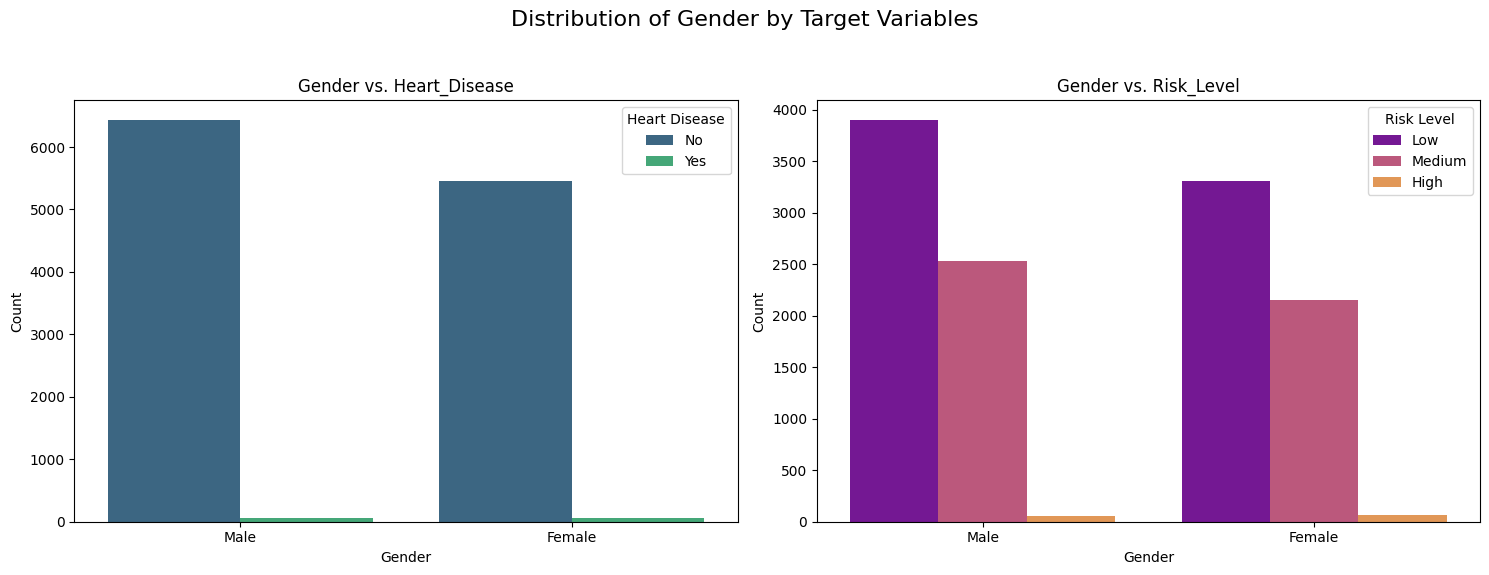

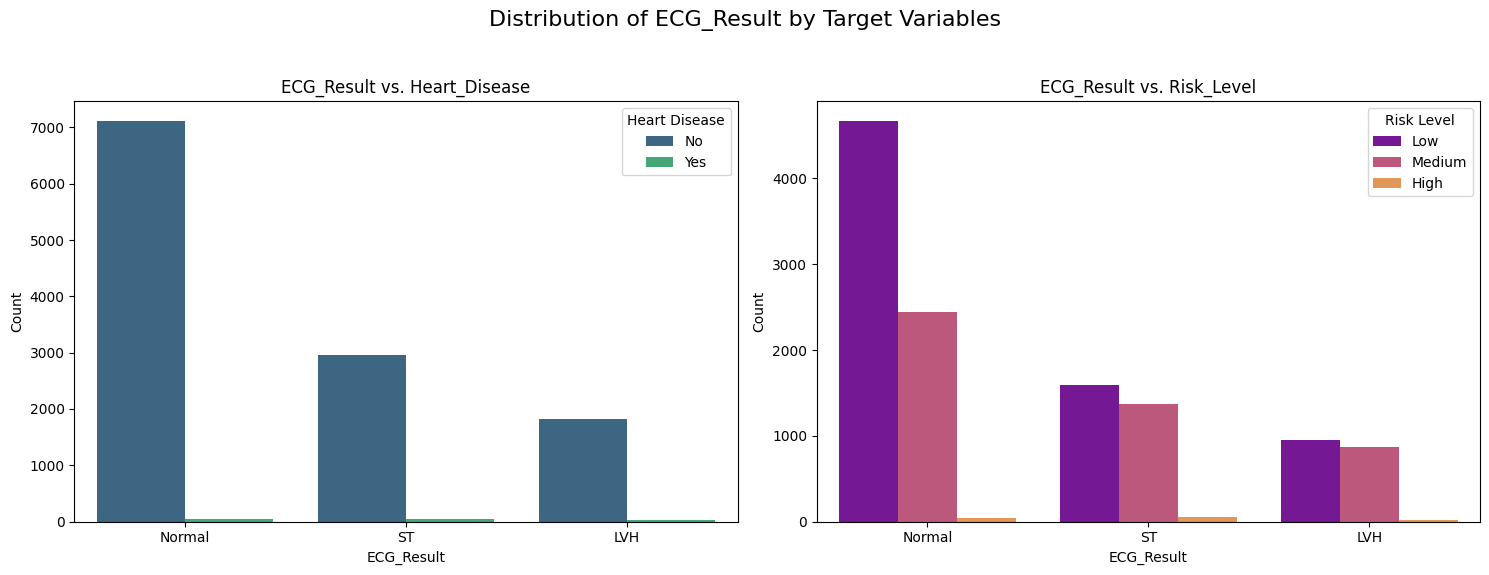

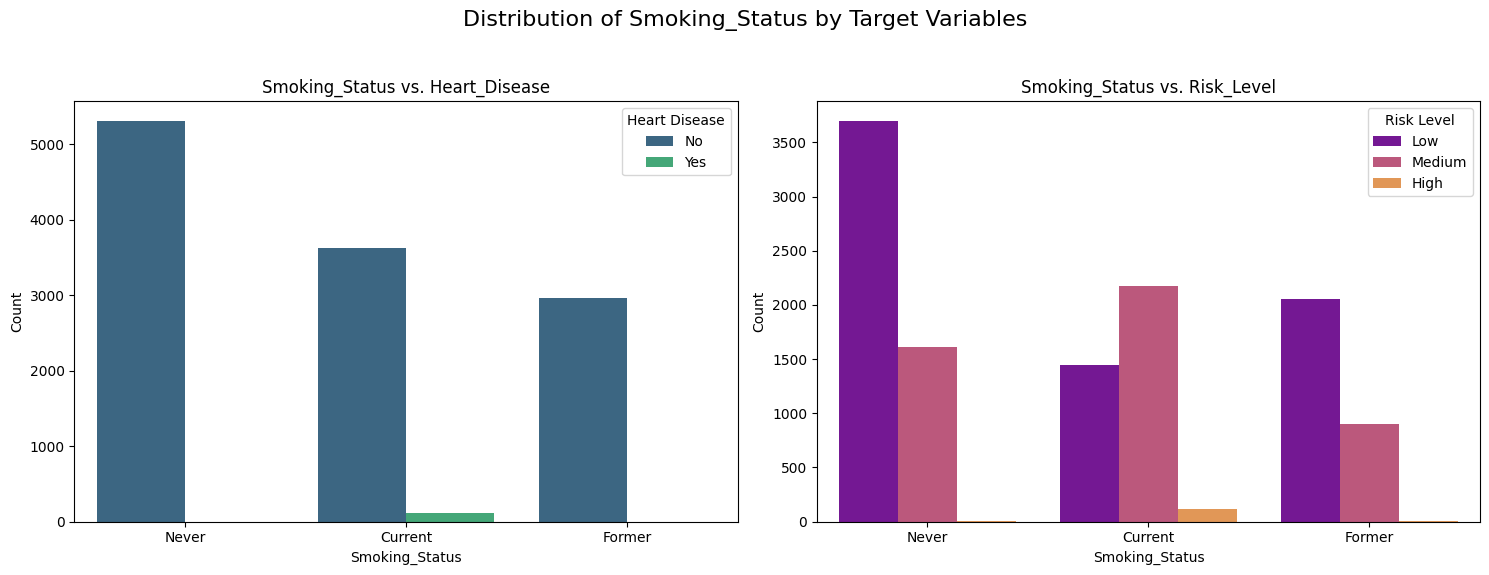

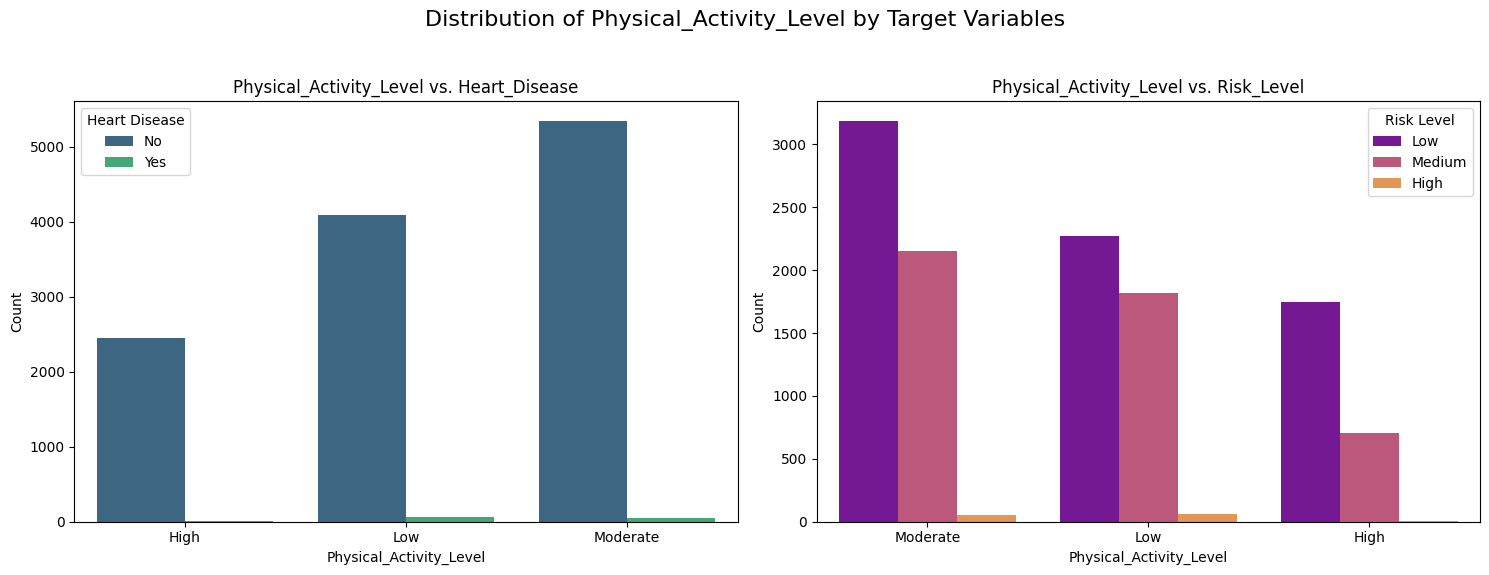

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


categorical_features = ['Gender', 'ECG_Result', 'Smoking_Status', 'Physical_Activity_Level']
target_variables = ['Heart_Disease', 'Risk_Level']

for feature in categorical_features:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Distribution of {feature} by Target Variables', fontsize=16)

    # Plot for Heart_Disease
    sns.countplot(data=df, x=feature, hue='Heart_Disease', palette='viridis', ax=axes[0])
    axes[0].set_title(f'{feature} vs. Heart_Disease')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Count')
    axes[0].legend(title='Heart Disease', labels=['No', 'Yes'])

    # Plot for Risk_Level
    sns.countplot(data=df, x=feature, hue='Risk_Level', palette='plasma', order=df[feature].value_counts().index, hue_order=['Low', 'Medium', 'High'], ax=axes[1])
    axes[1].set_title(f'{feature} vs. Risk_Level')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Count')
    axes[1].legend(title='Risk Level')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

**Observations:**

- **Gender:** Heart disease cases are very rare across both genders, consistent
  with the class imbalance identified earlier. Males have a slightly larger
  overall count in the dataset. Risk level distribution is proportionally similar
  between males and females — gender alone does not appear to be a strong
  differentiator.

- **ECG Result:** The majority of records show a Normal ECG result. Heart disease
  positive cases are tiny across all three ECG categories (Normal, ST, LVH),
  again reflecting the class imbalance. Notably, the High risk group is nearly
  absent across all ECG types, suggesting ECG result alone doesn't cleanly
  separate risk levels.

- **Smoking Status:** This is the most interesting plot, as **Current smokers**
  show a visibly higher proportion of heart disease (Yes) compared to Never and
  Former smokers. On the risk level side, Current smokers also have a noticeably
  higher share of Medium risk. This suggests smoking status has a meaningful
  relationship with both target variables.

- **Physical Activity Level:** Heart disease positive cases appear slightly more
  common in the Low activity group relative to its size. On the risk level side,
  the High activity group has almost no High-risk individuals, while Low activity
  has a larger Medium risk proportion — suggesting physical activity level has a
  protective relationship with risk.

## Correlation Analysis of Numerical Features

### Subtask:
Calculate and visualize the correlation matrix for all numerical features to identify strong positive or negative relationships.

#### Instructions:
1.  **Calculate Correlation Matrix:** Use the `.corr()` method on the DataFrame, selecting only numerical columns.
2.  **Visualize Heatmap:** Create a heatmap using `seaborn.heatmap()` to display the correlation matrix. Ensure the heatmap is clear and readable with annotations.
3.  **Ensure Readability:** Use `matplotlib.pyplot` to set an appropriate figure size and title.

#**4. Numerical Feature Analysis**
For each continuous feature, we examine its distribution and how it varies across the two target variables using histograms, KDE plots, and box plots.


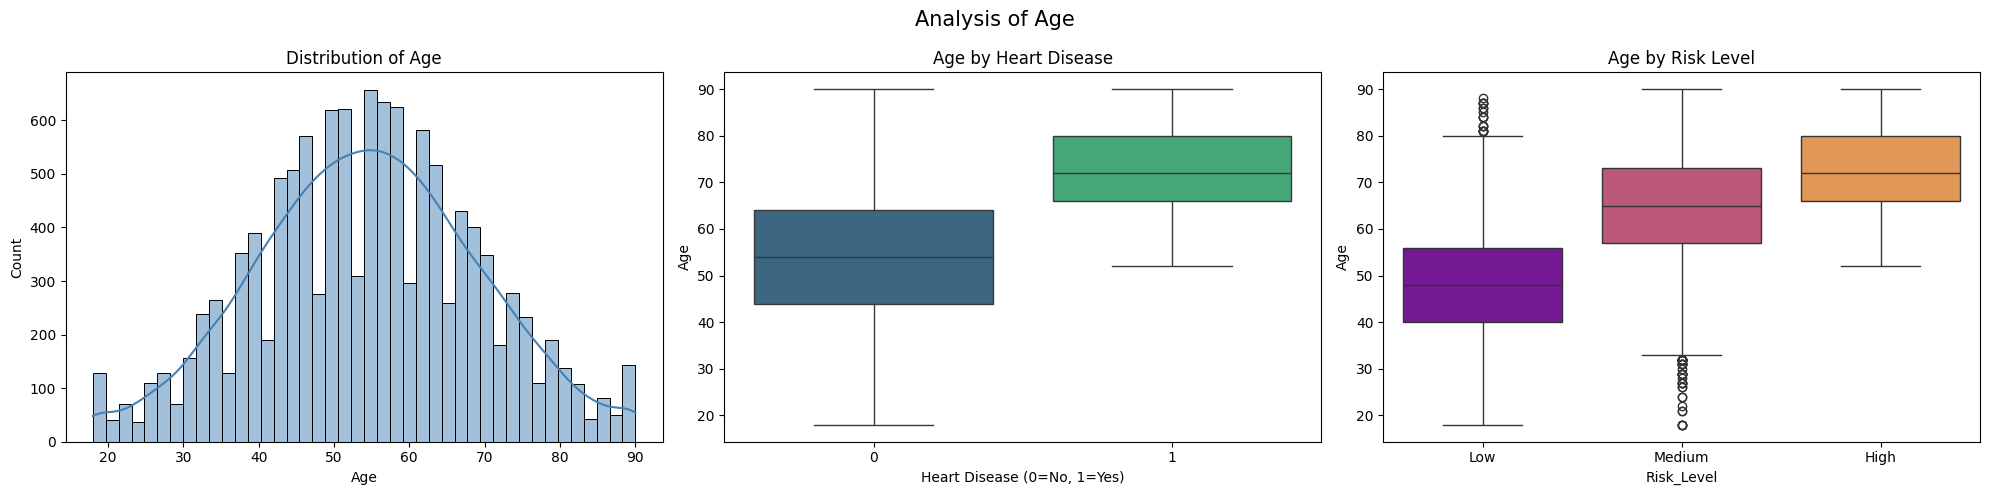

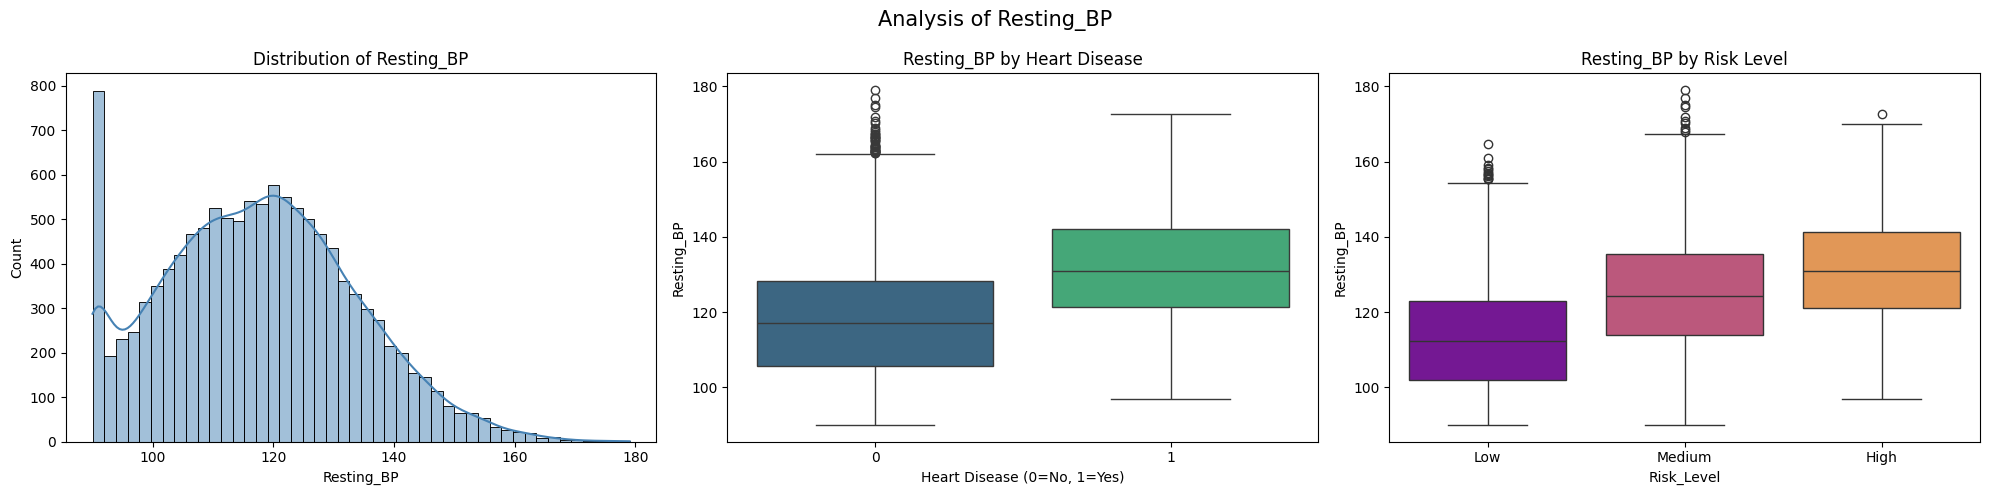

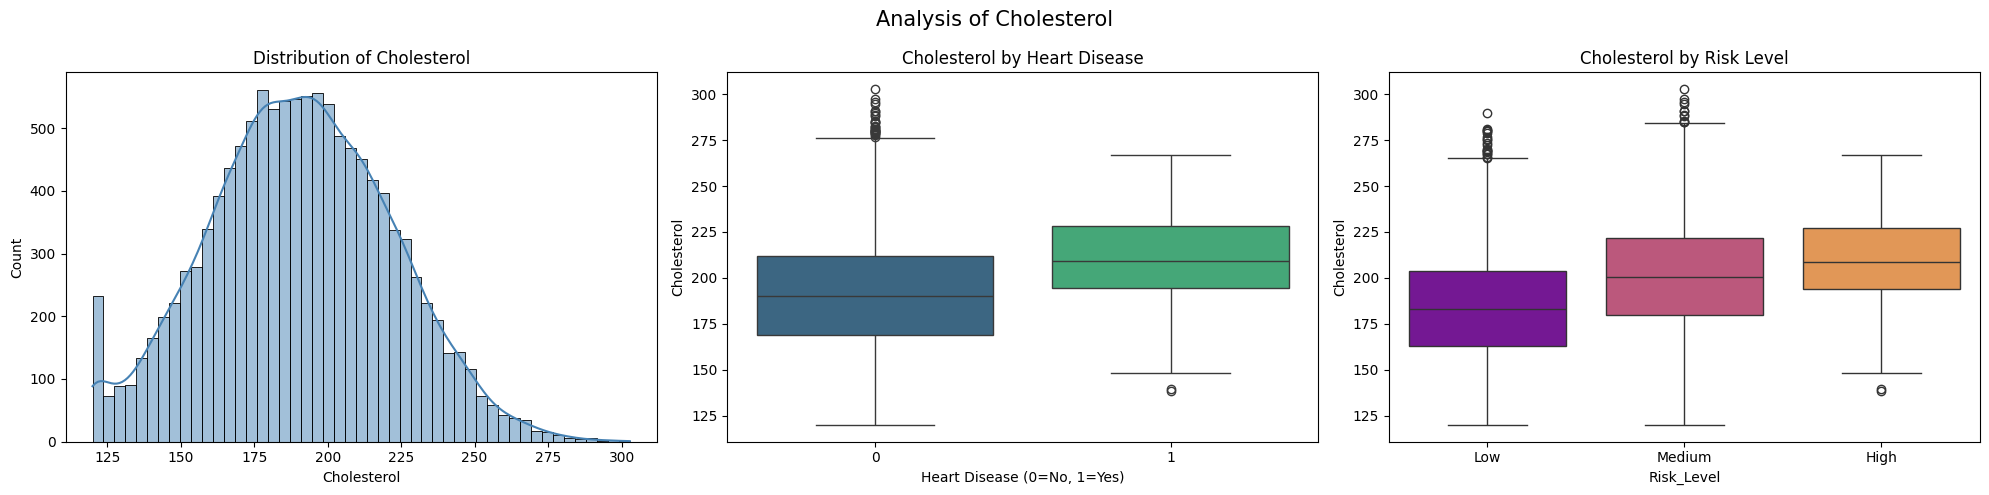

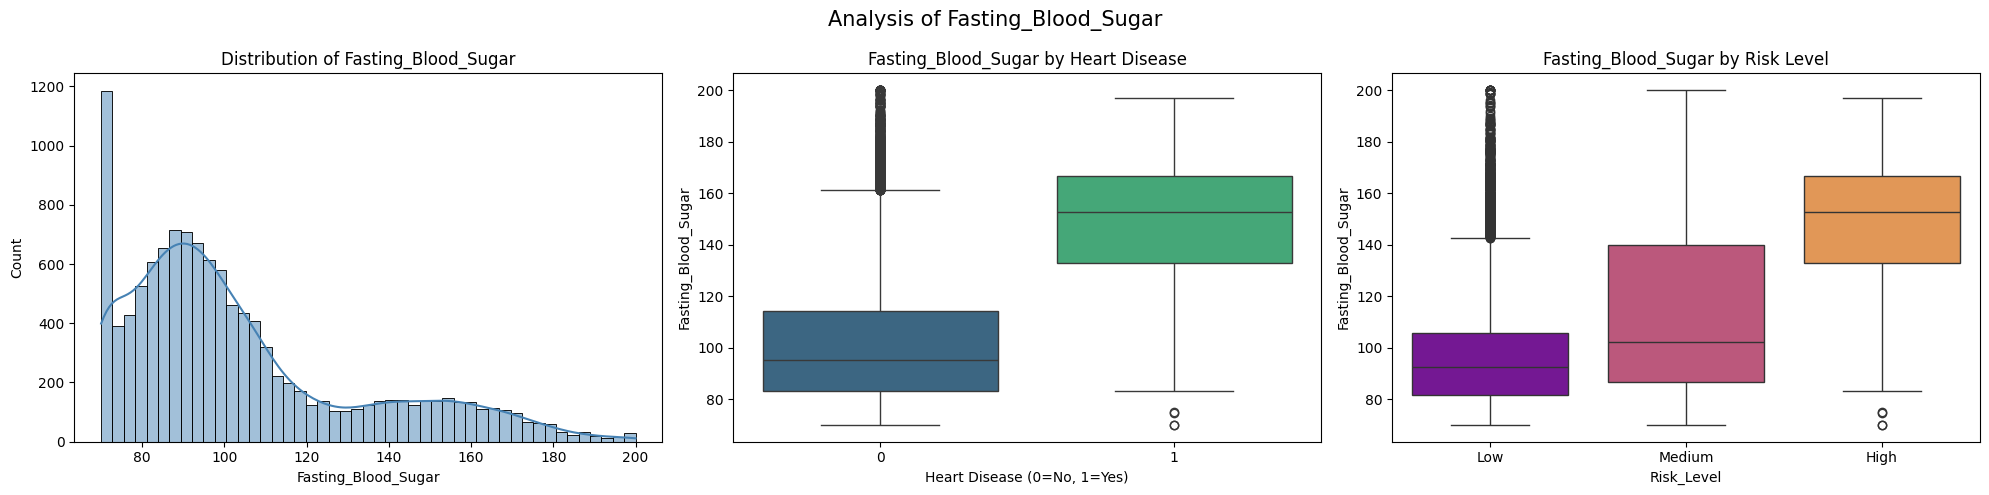

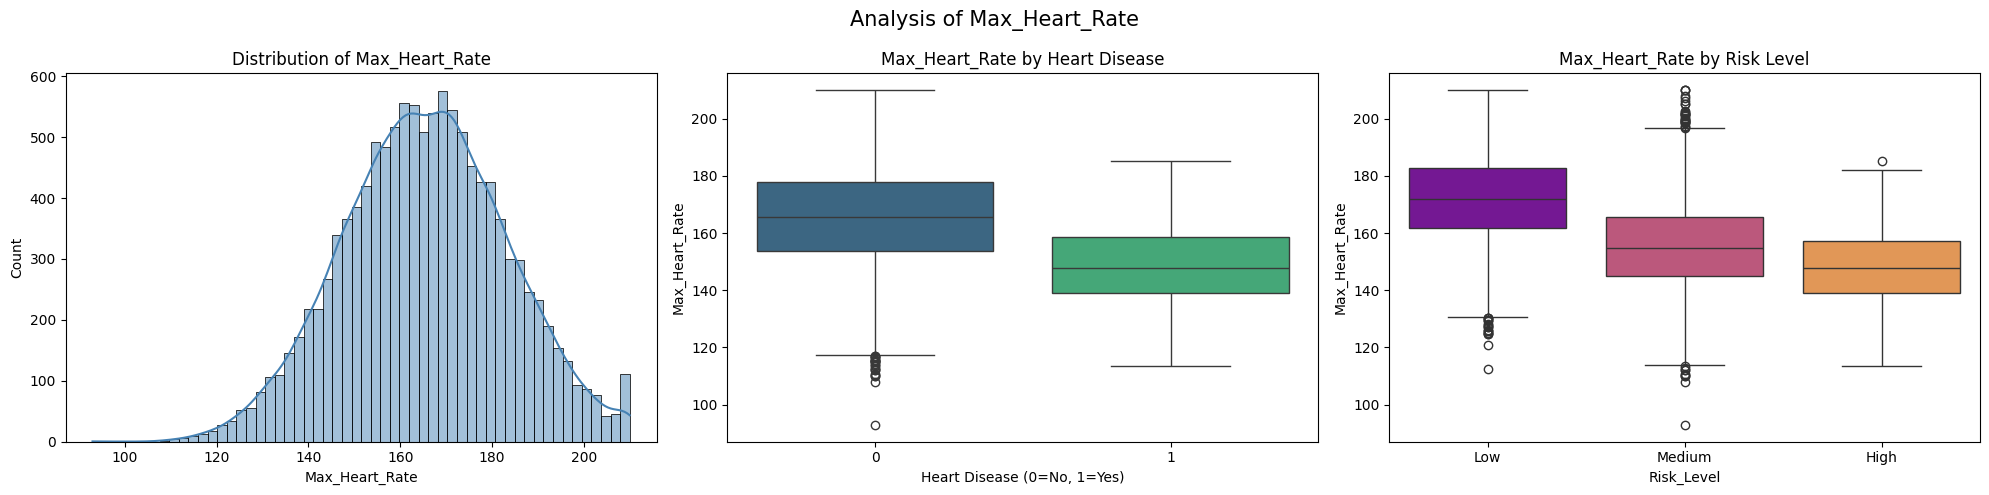

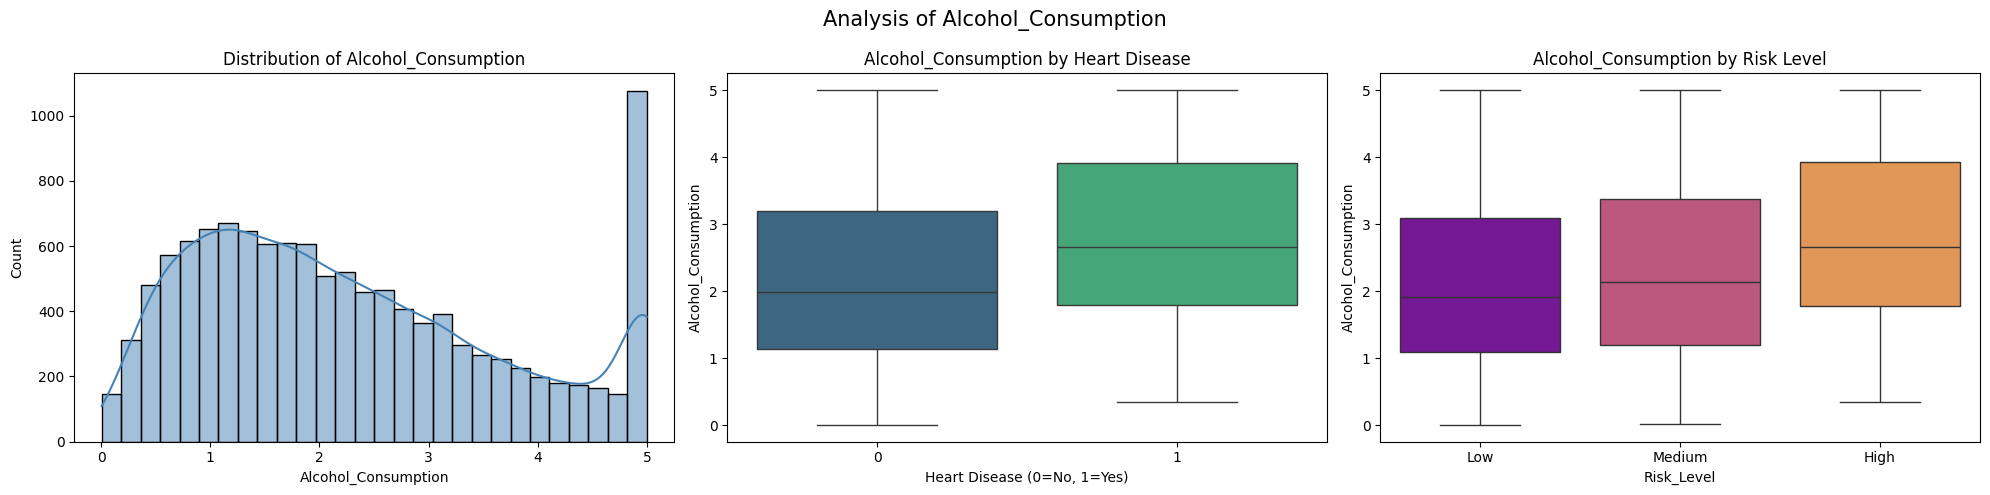

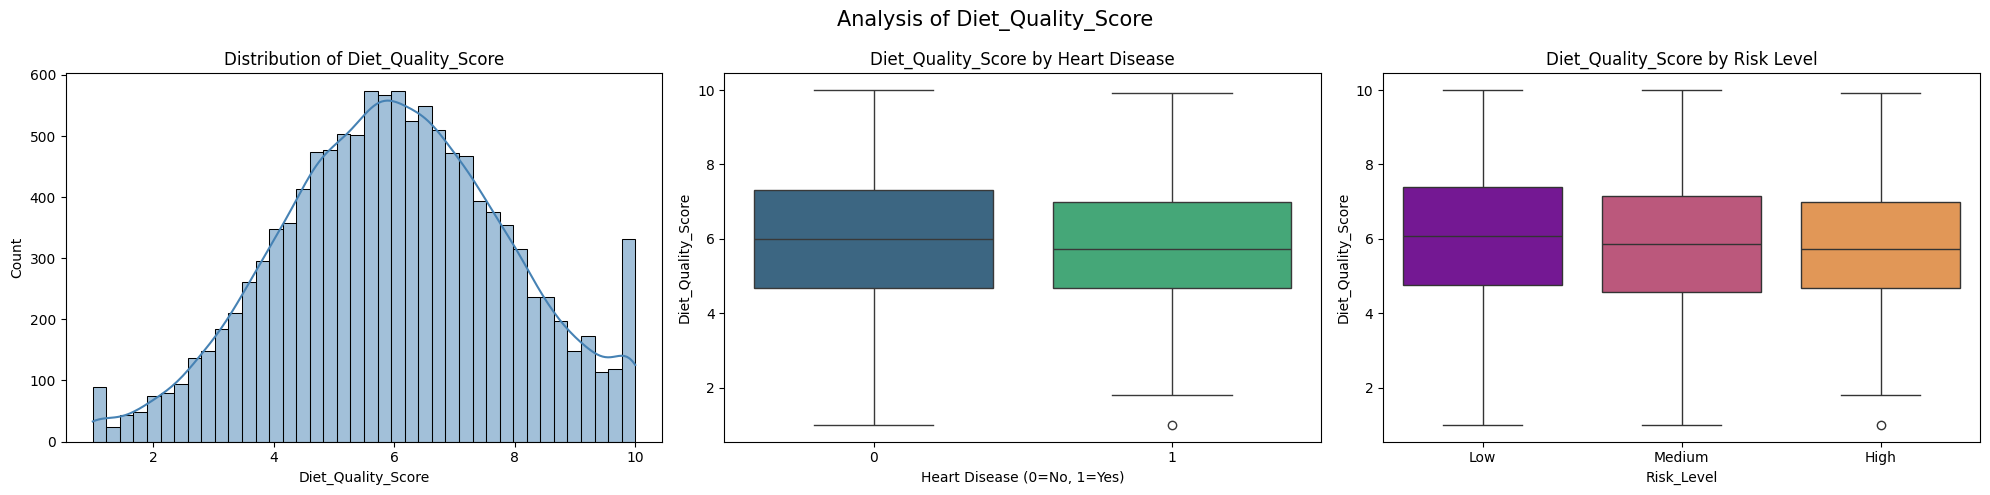

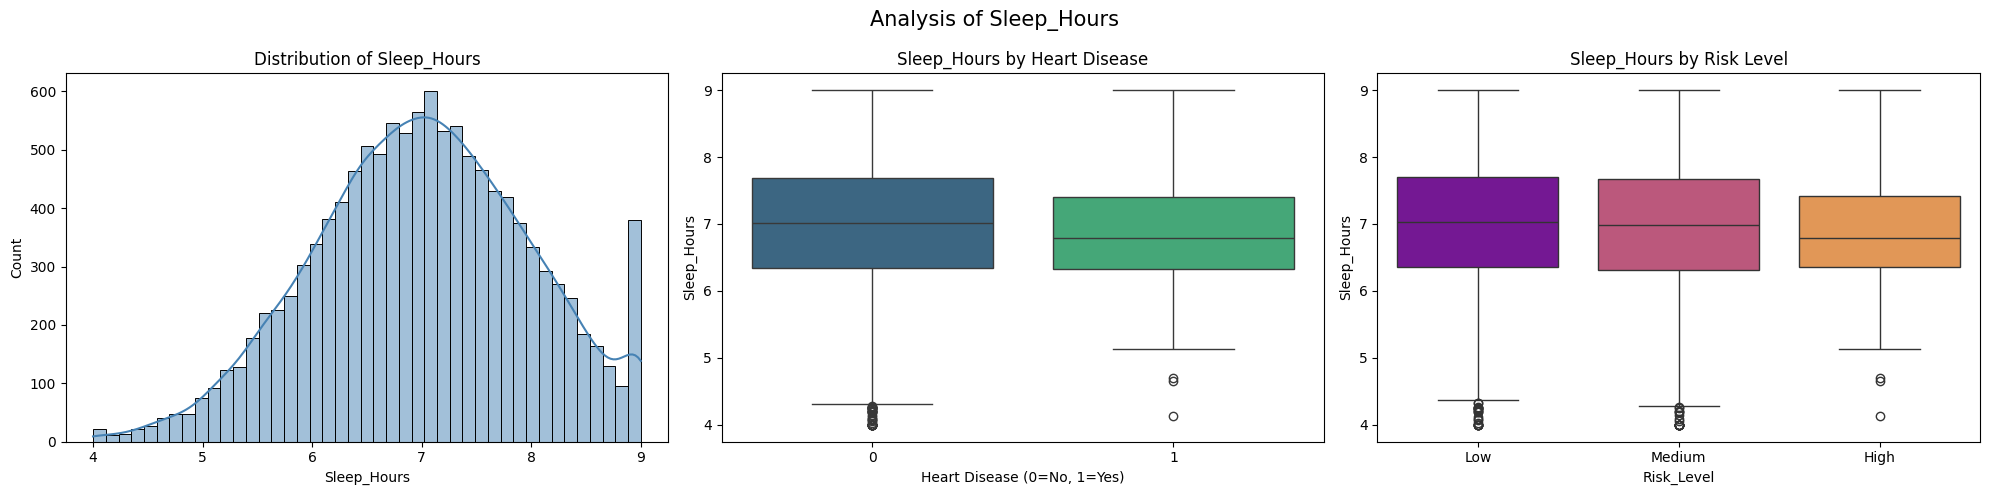

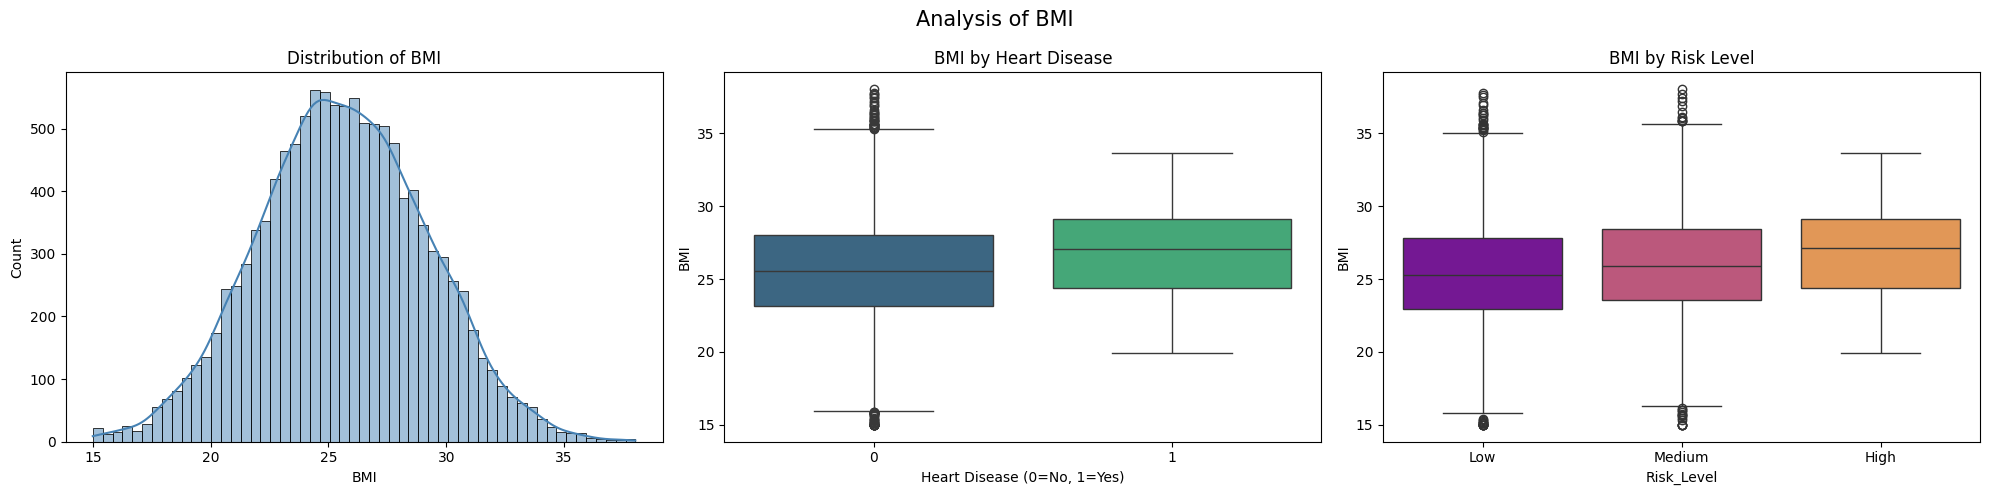

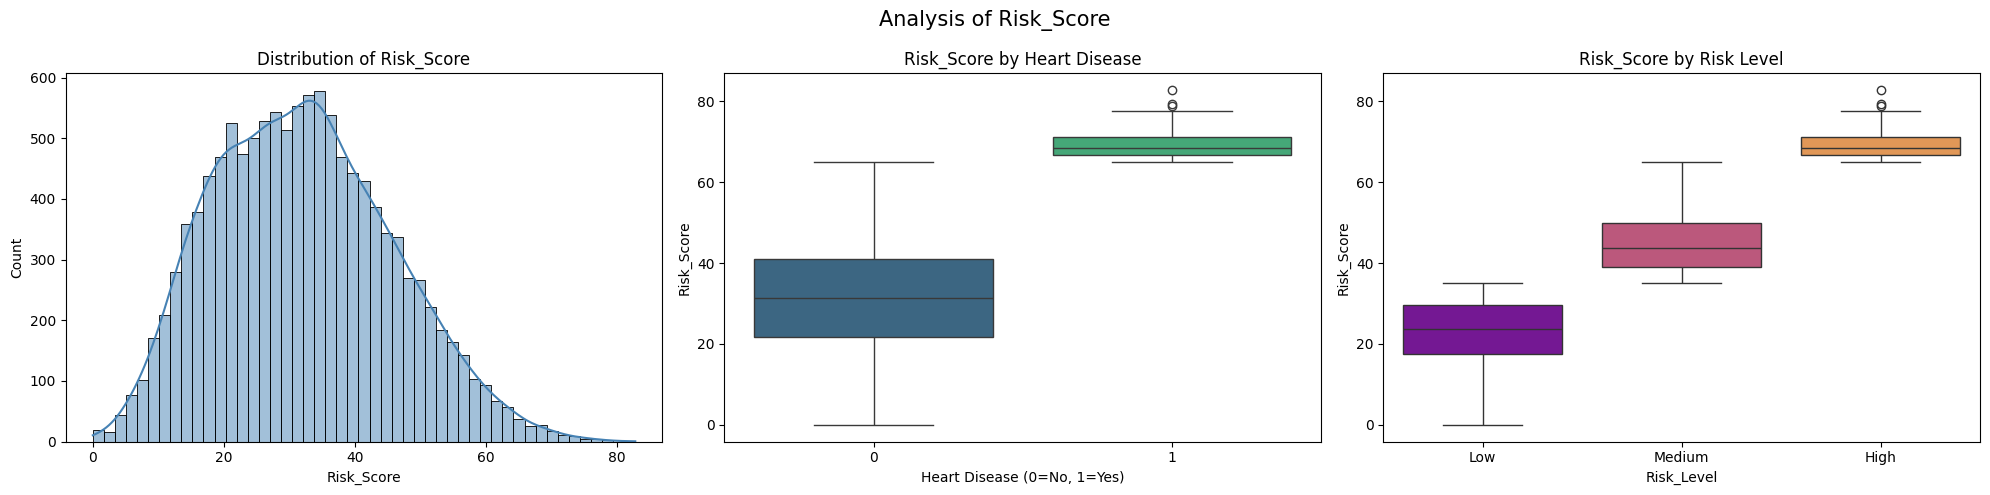

In [10]:
import warnings
warnings.filterwarnings('ignore')

numerical_features = [
    'Age', 'Resting_BP', 'Cholesterol', 'Fasting_Blood_Sugar',
    'Max_Heart_Rate', 'Alcohol_Consumption', 'Diet_Quality_Score',
    'Sleep_Hours', 'BMI', 'Risk_Score'
]

for feature in numerical_features:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Analysis of {feature}', fontsize=15)

    # Distribution
    sns.histplot(data=df, x=feature, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Distribution of {feature}')

    # vs Heart Disease
    sns.boxplot(data=df, x='Heart_Disease', y=feature,
                palette='viridis', ax=axes[1])
    axes[1].set_title(f'{feature} by Heart Disease')
    axes[1].set_xlabel('Heart Disease (0=No, 1=Yes)')

    # vs Risk Level
    sns.boxplot(data=df, x='Risk_Level', y=feature,
                order=['Low', 'Medium', 'High'],
                palette='plasma', ax=axes[2])
    axes[2].set_title(f'{feature} by Risk Level')

    plt.tight_layout()
    plt.show()

**Observations:**

- **Age:** Right-skewed distribution, with most patients between 40-70.
  Heart disease positive cases have a noticeably higher median age ( around 72)
  compared to negative cases (around 52). Age also increases steadily across
  Low → Medium → High risk levels, making it one of the stronger
  predictors in this dataset.

- **Resting_BP:** Slightly right-skewed, centered around 115-125.
  Heart disease cases show a higher median BP (around 132) vs. no disease (around 118).
  Risk level follows the same pattern — BP rises with risk level.
  A meaningful predictor.

- **Cholesterol:** Roughly bell-shaped, centered around 175-200.
  Heart disease cases have a slightly higher median cholesterol, and
  values increase gradually across risk levels. The difference is modest
  but consistent.

- **Fasting_Blood_Sugar:** Right-skewed with most values under 120.
  This feature shows one of the clearest separations — heart disease
  cases have a much higher median (around 150) vs. no disease (around 100), and
  High risk has a notably elevated median compared to Low. A strong
  signal worth flagging.

- **Max_Heart_Rate:** Left-skewed, most values between 140-180.
  Shows an **inverse** relationship — heart disease cases have a *lower*
  median max heart rate (around 150) vs. no disease (around 163). Same pattern
  across risk levels: High risk has a lower max heart rate than Low.
  This is clinically consistent — reduced cardiac capacity is associated
  with disease.

- **Alcohol_Consumption:** Unusual spike at value 5, suggesting possible
  capping or encoding of a maximum value. Heart disease cases show a
  slightly higher median. The relationship with risk level is mild but
  present — High risk has a marginally elevated median.

- **Diet_Quality_Score:** Fairly uniform distribution. Box plots show
  almost identical distributions across both heart disease groups and
  all risk levels — this feature does not appear to be a strong
  differentiator in this dataset.

- **Sleep_Hours:** Roughly normal, centered around 6.5-7.5 hours.
  Very little difference across heart disease groups or risk levels —
  sleep hours appears to have minimal predictive signal here.

- **BMI:** Roughly normal, centered around 22-27. Heart disease cases
  show a slightly higher median BMI, and High risk has a marginally
  higher median than Low. The difference is subtle but in the expected
  direction.

- **Risk_Score:** This is the clearest separator of all features.
  Risk levels separate almost perfectly by Risk_Score, confirming
  it's a **composite/derived variable** — likely computed from other
  features — and would need to be excluded from any predictive model
  to avoid data leakage.

#**5. Correlation Analysis**

Computing and visualizing the Pearson correlation matrix across all numerical features to identify multicollinearity and feature relationships.

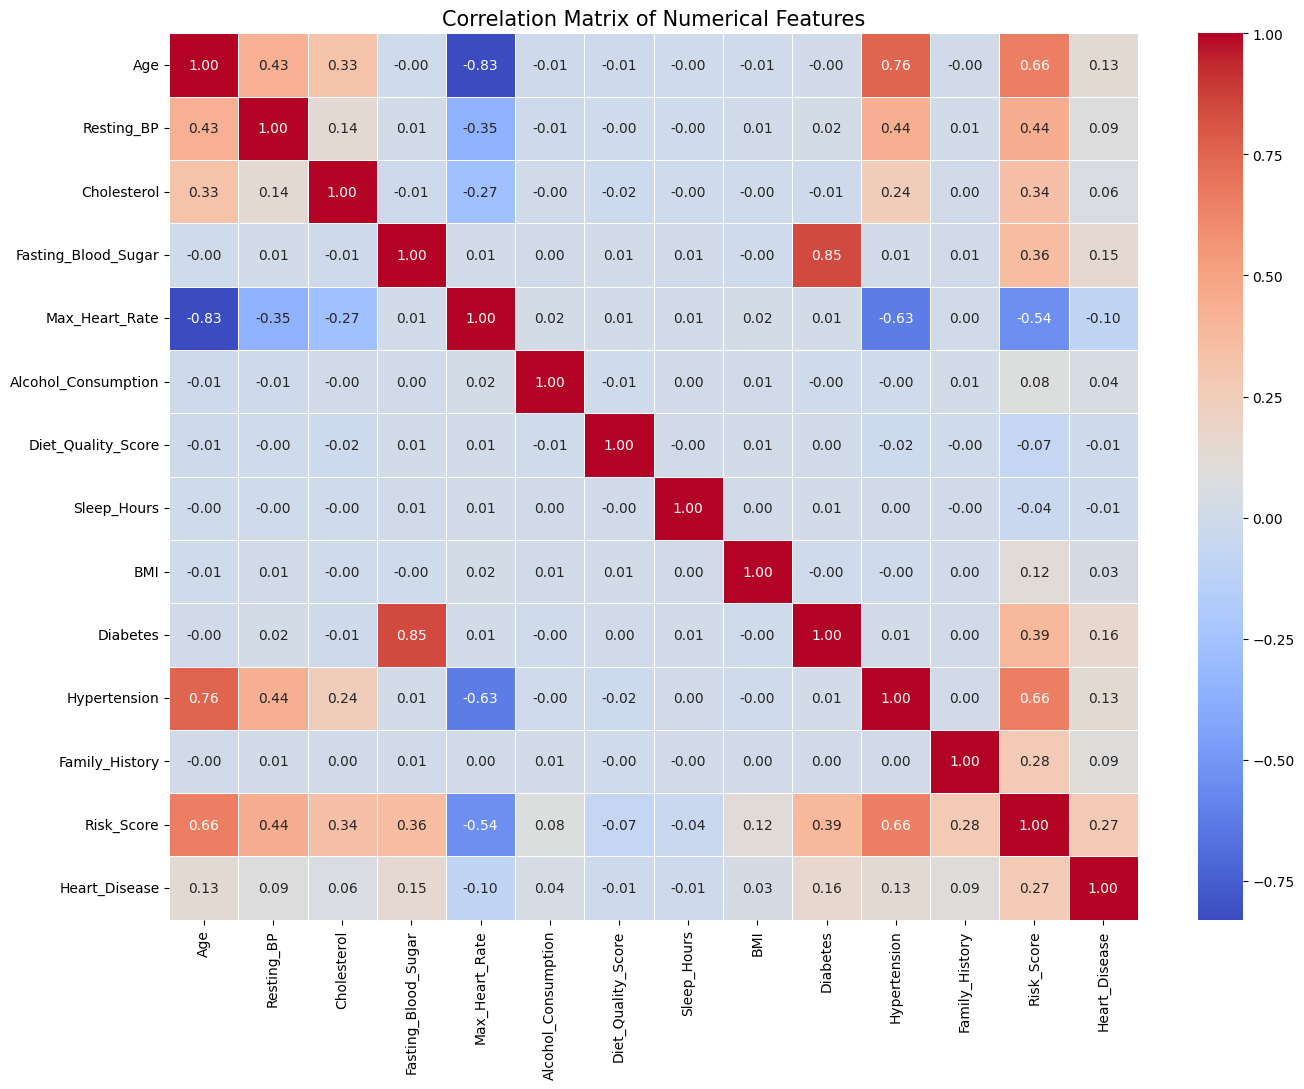

In [11]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.tight_layout()
plt.show()

**Observations:**

- **Age & Hypertension (0.76):** The strongest real-world correlation
  in the dataset, older patients are much more likely to have
  hypertension.

- **Age & Max_Heart_Rate (-0.83):** The strongest correlation overall.
  As age increases, maximum heart rate decreases, a well-known
  physiological relationship.

- **Hypertension & Max_Heart_Rate (-0.63):** Hypertensive patients
  tend to have lower max heart rates, likely because hypertension and
  age are so closely linked.

- **Fasting_Blood_Sugar & Diabetes (0.85):** Very strong, expected
  relationship, high fasting blood sugar is a defining characteristic
  of diabetes.

- **Risk_Score correlations:** Risk_Score is moderately correlated with
  Age (0.66), Hypertension (0.66), Resting_BP (0.44), and
  Fasting_Blood_Sugar (0.36), confirming it is a composite variable
  derived from these features, so it should be **excluded from any
  predictive model** to prevent data leakage.

- **Most other features** (Alcohol_Consumption, Diet_Quality_Score,
  Sleep_Hours, BMI): Correlations near 0.00 across the board,
  these features are largely independent of each other and of the
  target variable, suggesting limited predictive power individually.

- **No severe multicollinearity** (outside of the Age/Hypertension
  and Fasting_Blood_Sugar/Diabetes pairs), which is generally good
  for modeling, most features carry independent information.